# Method Comparison — Stage 6 Oracle Simulation

Generic analysis notebook for any model / workload / tree config produced
by the Stage 6 pipeline. Auto-discovers all `{workload}_steps{N}/`
directories under the selected `MODEL_DIR`, then renders bar charts /
scatter / budget sensitivity for one configuration at a time.

**Usage**:
1. Set `MODEL_DIR` to the model's output root (e.g. `../results/qwen3_14b`).
2. Pick `SELECTED` from the auto-discovered keys (printed when the
   config cell runs).
3. Optionally toggle `USE_REAL_COST` and `RATIO_CHART_BUDGET`.

Sections 1–6 operate on the selected config. Section 7 overlays the
selected workload's steps sweep (e.g. specbench steps={2,4,6,8}).
Section 8 compares workloads at the same steps.

In [303]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 100,
})

In [304]:
# ========== SELECT CONFIG AND COST MODE HERE ==========
import os
import re
from pathlib import Path

# >>> CHANGE THESE <<<
MODEL_DIR = "../results/qwen3_14b"
USE_REAL_COST = True       # True = measured latencies, False = ratio-based
RATIO = 0.1                # only used when USE_REAL_COST = False
RATIO_CHART_BUDGET = 256   # reference budget for the ratio-sweep chart (§4)
# Leave SELECTED = None to auto-pick the first available key,
# or set to a specific short key (e.g. "specbench_steps2", "bfcl_v4_req576-579").
SELECTED = "specbench_steps2"

# Auto-discover any sub-directory that contains tree_oracle_sim.json
# (or tree_oracle_sim_ours.json — takes priority when both exist).
# Understands both Phase 5 `{workload}_steps{N}` and legacy
# `{workload}_req{start}-{end}` naming conventions.
WORKLOAD_OPTIONS = {}
_rgx_steps = re.compile(r"^(.+)_steps(\d+)$")
_rgx_req   = re.compile(r"^(.+)_req([0-9]+-[0-9]+)$")

def _parse_dir_name(name):
    """Return (workload, axis, axis_value) or (name, None, None)."""
    m = _rgx_steps.match(name)
    if m:
        return m.group(1), "steps", int(m.group(2))
    m = _rgx_req.match(name)
    if m:
        return m.group(1), "req", m.group(2)
    return name, None, None

_base = Path(MODEL_DIR)
if _base.exists():
    for sub in sorted(_base.iterdir()):
        if not sub.is_dir():
            continue
        # Prefer tree_oracle_sim_ours.json if present (re-simulation with our cost)
        ours = sub / "tree_oracle_sim_ours.json"
        default = sub / "tree_oracle_sim.json"
        path = ours if ours.exists() else default
        if not path.exists():
            continue
        workload, axis, ax_val = _parse_dir_name(sub.name)
        if axis == "steps":
            tag = f"steps={ax_val}"
        elif axis == "req":
            tag = f"req{ax_val}"
        else:
            tag = ""
        label = f"{workload} {tag}".strip()
        WORKLOAD_OPTIONS[sub.name] = (label, str(path))

if not WORKLOAD_OPTIONS:
    raise RuntimeError(
        f"No tree_oracle_sim*.json found under {MODEL_DIR}.")

if SELECTED is None:
    SELECTED = next(iter(WORKLOAD_OPTIONS))
if SELECTED not in WORKLOAD_OPTIONS:
    raise RuntimeError(
        f"SELECTED='{SELECTED}' not found. Available: {list(WORKLOAD_OPTIONS.keys())}")

print(f"Available configs: {list(WORKLOAD_OPTIONS.keys())}")
print(f"→ SELECTED = '{SELECTED}'")
print()

workload_name, workload_path = WORKLOAD_OPTIONS[SELECTED]
with open(workload_path) as f:
    data = json.load(f)

# vanilla_step_ms: prefer per-run latency_config_ours (if present), then
# per-run latency_config, then shared model-level config.
latency_candidates = [
    Path(workload_path).parent / "latency_config_ours.json",
    Path(workload_path).parent / "latency_config.json",
    Path(MODEL_DIR) / "latency_config.json",
]
vanilla_ms = None
for lp in latency_candidates:
    if not lp.exists():
        continue
    try:
        with open(lp) as f:
            lc = json.load(f)
        vanilla_ms = lc['vanilla_step_ms']
        print(f"Loaded vanilla_step_ms={vanilla_ms:.3f} from {lp}")
        break
    except Exception:
        continue
if vanilla_ms is None:
    vanilla_ms = float(data.get('latency', {}).get('vanilla_step_ms', 0.0)) or 1.0
    print(f"Using fallback vanilla_step_ms={vanilla_ms:.3f}")

COST_LABEL = "real cost" if USE_REAL_COST else f"ratio={RATIO}"

print()
print(f"Workload: {SELECTED} — {workload_name}")
if USE_REAL_COST:
    print("Draft cost: REAL (measured latencies)")
else:
    print(f"Draft cost ratio: {RATIO} (step = verify × {1+RATIO:.2f})")
print(f"Ratio-chart reference budget (§4 only): B={RATIO_CHART_BUDGET}")

Available configs: ['bfcl_v4_steps2', 'bfcl_v4_steps4', 'bfcl_v4_steps6', 'bfcl_v4_steps8', 'specbench_steps2', 'specbench_steps4', 'specbench_steps6', 'specbench_steps8', 'swebench_steps2']
→ SELECTED = 'specbench_steps2'

Loaded vanilla_step_ms=28.233 from ../results/qwen3_14b/specbench_steps2/latency_config.json

Workload: specbench_steps2 — specbench steps=2
Draft cost: REAL (measured latencies)
Ratio-chart reference budget (§4 only): B=256


In [305]:
# Parse budget table
df = pd.DataFrame(data["latency"]["budget_sweep"])

# Speedup key: real-cost or ratio-based
spd_suffix = "_speedup_real" if USE_REAL_COST else f"_speedup_r{RATIO}"

# Hide: Choose-One oracle methods are excluded from charts. They require
# ground-truth proposer selection per step (true oracle), so showing them
# alongside realistic methods can be misleading.
HIDE_METHODS = {'c1', 'c1_e3sfx'}

# Always-at-max-budget: suffix (budget-independent, benefits from full tree)
MAX_BUDGET_METHODS = {'suffix'}

max_budget = int(df['budget'].max())
methods = []
for col in df.columns:
    if col.endswith(spd_suffix):
        name = col.replace(spd_suffix, '')
        if name.endswith('_always'):
            continue
        if name in HIDE_METHODS:
            continue
        if name in MAX_BUDGET_METHODS:
            row = df[df['budget'] == max_budget]
            idx = row.index[0]
        else:
            # All other methods (including extension variants) pick the
            # budget that maximizes speedup, not a fixed oracle budget.
            idx = df[col].idxmax()
        best_b = int(df['budget'].iloc[idx])
        mc = f'{name}_mat'
        methods.append({
            'method': name,
            'best_budget': best_b,
            'speedup': df[col].iloc[idx],
            'mat': df[mc].iloc[idx] if mc in df.columns else 0,
        })

mdf = pd.DataFrame(methods)

# Keep only best threshold per hybrid group
for prefix in ['hybrid_e3_t', 'hybrid_dm_t']:
    mask = mdf['method'].str.startswith(prefix)
    group = mdf[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf = mdf.drop(drop_idx)

# Keep only best threshold per extension_by_score group
for prefix in ['extension_by_score_t', 'extension_dmsfx_by_score_t']:
    mask = mdf['method'].str.startswith(prefix)
    group = mdf[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf = mdf.drop(drop_idx)
mdf = mdf.reset_index(drop=True)

# Labels
def make_label(name):
    labels = {
        'eagle3': 'EAGLE3',
        'suffix': 'Suffix',
        'draft_model': 'Draft Model',
        'extension': 'Extension (E3+Sfx)',
        'extension_dmsfx': 'Extension (DM+Sfx)',
        'extension_oracle': 'Ext(E3+Sfx) oracle',
        'extension_dmsfx_oracle': 'Ext(DM+Sfx) oracle',
        'extension_by_count': 'Ext(E3+Sfx,count)',
        'extension_dmsfx_by_count': 'Ext(DM+Sfx,count)',
    }
    if name in labels:
        return labels[name]
    if name.startswith('hybrid_e3'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->E3) t={t}'
    if name.startswith('hybrid_dm'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->DM) t={t}'
    if name.startswith('extension_dmsfx_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(DM+Sfx,score) t={t}'
    if name.startswith('extension_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,score) t={t}'
    return name

# Display order — baselines → hybrid → extension → extension variants
ORDER = [
    'eagle3', 'suffix', 'draft_model',
    'hybrid_e3', 'hybrid_dm',
    'extension', 'extension_dmsfx',
    'extension_by_count', 'extension_dmsfx_by_count',
    'extension_by_score', 'extension_dmsfx_by_score',
    'extension_oracle', 'extension_dmsfx_oracle',
]

def get_order(name):
    if name.startswith('hybrid_e3'):
        return ORDER.index('hybrid_e3')
    if name.startswith('hybrid_dm'):
        return ORDER.index('hybrid_dm')
    if name.startswith('extension_dmsfx_by_score'):
        return ORDER.index('extension_dmsfx_by_score')
    if name.startswith('extension_by_score'):
        return ORDER.index('extension_by_score')
    return ORDER.index(name) if name in ORDER else len(ORDER)

def get_color(name):
    if name == 'eagle3': return '#2ca02c'
    if name == 'suffix': return '#ff7f0e'
    if name == 'draft_model': return '#8c564b'
    if 'hybrid_e3' in name: return '#9467bd'
    if 'hybrid_dm' in name: return '#e377c2'
    if name == 'extension': return '#d62728'
    if name == 'extension_dmsfx': return '#fc8d8d'
    if name == 'extension_oracle': return '#7a0000'       # deep red
    if name == 'extension_dmsfx_oracle': return '#a83232'
    if name == 'extension_by_count': return '#ef4040'     # lighter red
    if name == 'extension_dmsfx_by_count': return '#ffa0a0'
    if name.startswith('extension_dmsfx_by_score'): return '#c94a4a'
    if name.startswith('extension_by_score'): return '#a51717'
    return '#7f7f7f'

mdf['label'] = mdf['method'].map(make_label)
mdf['color'] = mdf['method'].map(get_color)
mdf['order'] = mdf['method'].map(get_order)
mdf = mdf.sort_values('order').reset_index(drop=True)

print(f"Methods: {len(mdf)}, cost={COST_LABEL}")
print(mdf[['label', 'best_budget', 'speedup', 'mat']].to_string(index=False))

Methods: 13, cost=real cost
                   label  best_budget  speedup      mat
                  EAGLE3           16 1.937152 1.213849
                  Suffix          512 0.850955 0.435519
             Draft Model            1 1.209541 0.694466
   Hybrid(Sfx->E3) t=5.0           16 2.052528 1.321352
   Hybrid(Sfx->DM) t=1.0            1 1.478138 0.759644
      Extension (E3+Sfx)            4 1.998818 1.420935
      Extension (DM+Sfx)            1 1.518084 1.136959
       Ext(E3+Sfx,count)           16 1.937163 1.213849
       Ext(DM+Sfx,count)            1 1.209541 0.694466
Ext(E3+Sfx,score) t=10.0           16 2.148582 1.574191
 Ext(DM+Sfx,score) t=1.0            1 1.604836 1.263012
      Ext(E3+Sfx) oracle           64 2.792937 2.139076
      Ext(DM+Sfx) oracle            1 1.641698 1.300529


## 1. Speedup Comparison

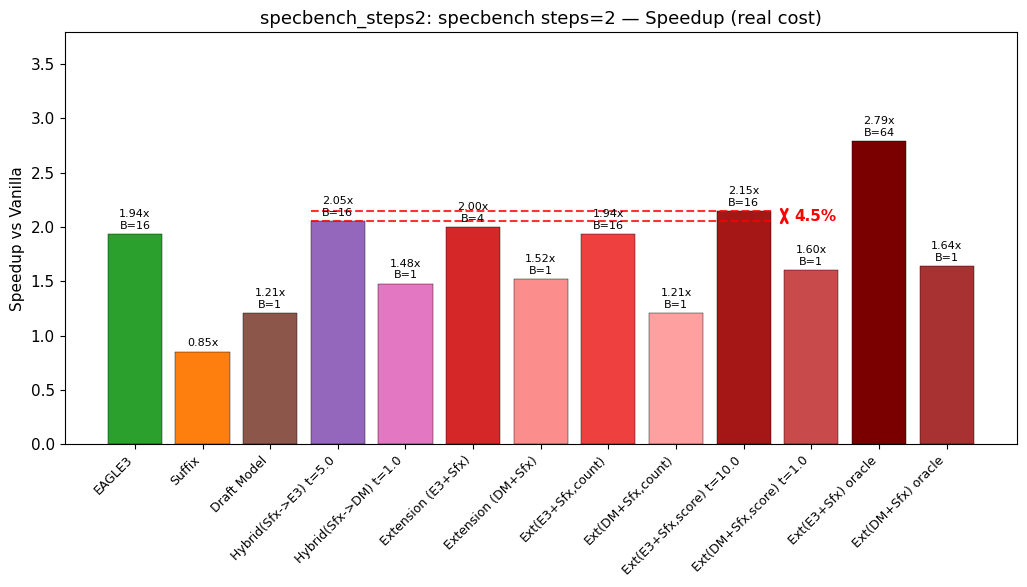

In [306]:
fig, ax = plt.subplots(figsize=(max(10, len(mdf) * 0.8), 6))

x = np.arange(len(mdf))
bars = ax.bar(x, mdf['speedup'].values, color=mdf['color'].values,
              edgecolor='black', linewidth=0.3)

_max_b = int(df['budget'].max())
for i, (spd, b) in enumerate(zip(mdf['speedup'].values, mdf['best_budget'].values)):
    if int(b) == _max_b:
        txt = f'{spd:.2f}x'
    else:
        txt = f'{spd:.2f}x\nB={b}'
    ax.text(i, spd + 0.03, txt, ha='center', va='bottom', fontsize=8)

# Gap annotation: best realistic extension (excluding oracle variants) vs
# best hybrid. The oracle methods are upper bounds (they assume knowing
# which suffix chains to verify beforehand) and so don't represent
# deployable settings — compare against practical extension instead.
def _is_hybrid(m):
    return (m.startswith('hybrid_e3_t') or m.startswith('hybrid_dm_t')) \
        and not m.endswith('_always')

def _is_realistic_extension(m):
    if not m.startswith('extension'):
        return False
    # Exclude the "oracle" variants (target verifies only accepted path).
    return not (m == 'extension_oracle' or m == 'extension_dmsfx_oracle')

methods_list = list(mdf['method'].values)
speedups_list = list(mdf['speedup'].values)

best_hyb = None
for i, m in enumerate(methods_list):
    if _is_hybrid(m):
        if best_hyb is None or speedups_list[i] > speedups_list[best_hyb]:
            best_hyb = i

best_ext = None
for i, m in enumerate(methods_list):
    if _is_realistic_extension(m):
        if best_ext is None or speedups_list[i] > speedups_list[best_ext]:
            best_ext = i

if best_hyb is not None and best_ext is not None:
    h_pos, e_pos = best_hyb, best_ext
    h_spd = speedups_list[h_pos]
    e_spd = speedups_list[e_pos]
    pct = abs((h_spd - e_spd) / max(h_spd, e_spd) * 100)

    x_lo, x_hi = sorted([h_pos, e_pos])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)

    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + e_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups_list) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED}: {workload_name} — Speedup ({COST_LABEL})', fontsize=13)
plt.tight_layout()
plt.show()

## 2. MAT (Mean Accepted Tokens) Comparison

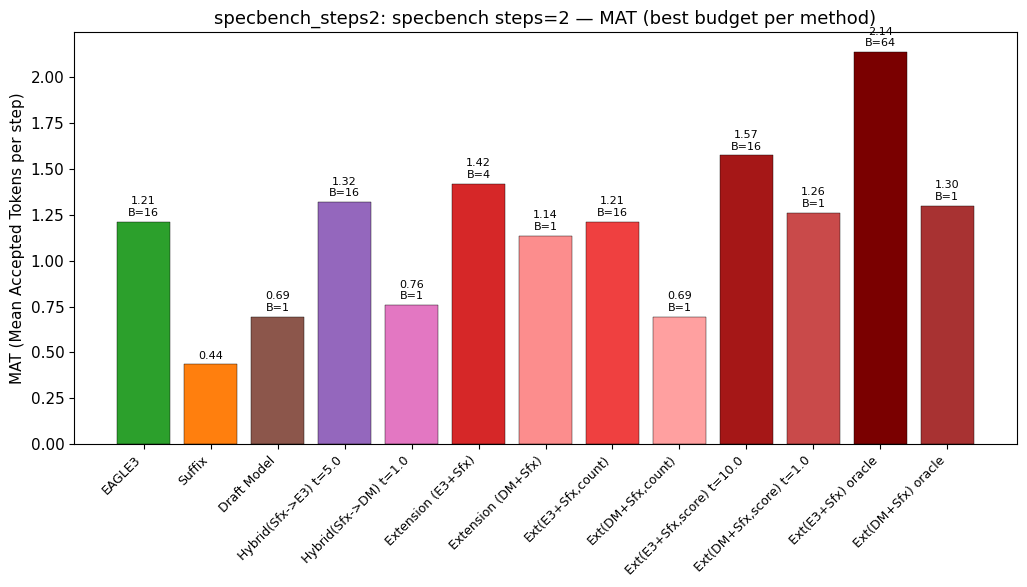

In [307]:
mdf_mat = mdf[mdf['mat'] > 0].copy()

if len(mdf_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf_mat) * 0.8), 6))
    
    x = np.arange(len(mdf_mat))
    bars = ax.bar(x, mdf_mat['mat'], color=mdf_mat['color'].values, edgecolor='black', linewidth=0.3)
    
    _max_b = int(df['budget'].max())
    for i, (mat, b) in enumerate(zip(mdf_mat['mat'], mdf_mat['best_budget'])):
        if int(b) == _max_b:
            txt = f'{mat:.2f}'
        else:
            txt = f'{mat:.2f}\nB={b}'
        ax.text(i, mat + 0.02, txt, ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(mdf_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED}: {workload_name} — MAT (best budget per method)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data available')

## 3. Speedup vs MAT Scatter

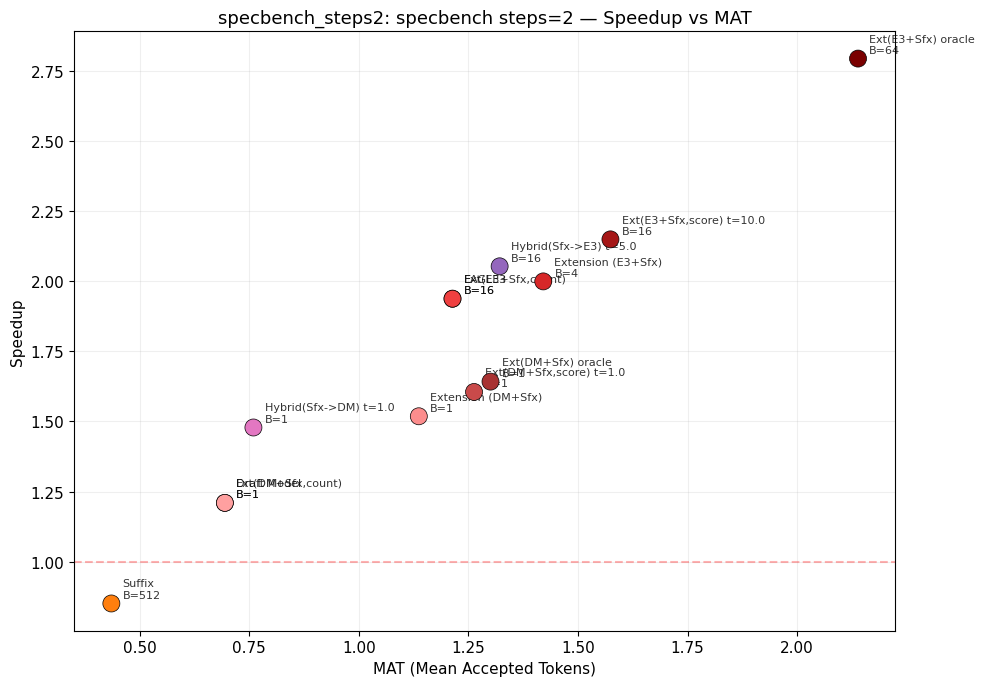

In [308]:
mdf_both = mdf[mdf['mat'] > 0].copy()

if len(mdf_both) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(mdf_both['mat'], mdf_both['speedup'],
               c=mdf_both['color'], s=150, edgecolors='black', linewidth=0.5, zorder=5)
    
    for _, r in mdf_both.iterrows():
        ax.annotate(f"{r['label']}\nB={r['best_budget']}",
                    (r['mat'], r['speedup']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, alpha=0.8)
    
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel('MAT (Mean Accepted Tokens)')
    ax.set_ylabel('Speedup')
    ax.set_title(f'{SELECTED}: {workload_name} — Speedup vs MAT', fontsize=13)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('No data')

## 4. Speedup across Ratios (Selected Budget)

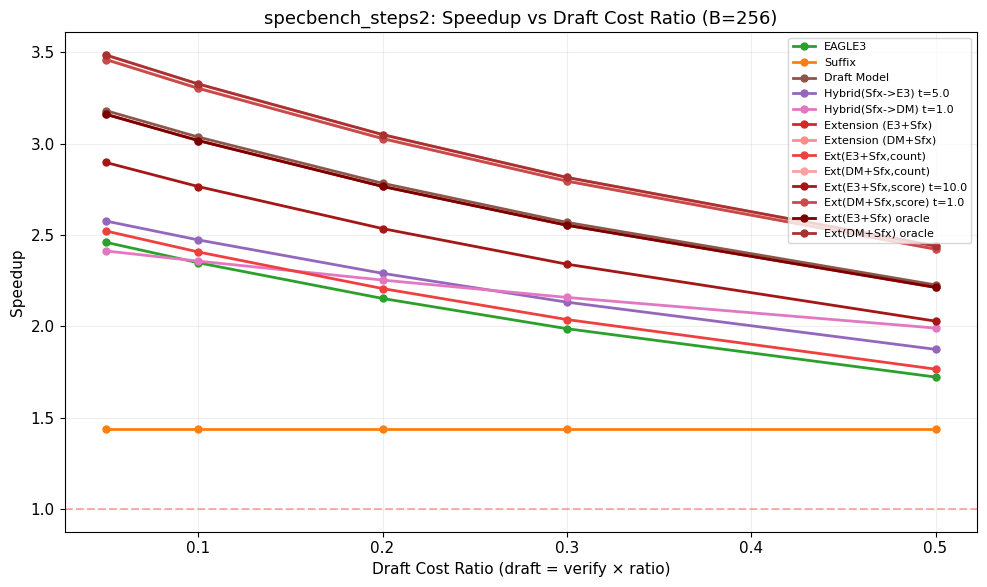

In [309]:
ratios = [0.05, 0.1, 0.2, 0.3, 0.5]
b_row = df[df['budget'] == RATIO_CHART_BUDGET]
if len(b_row) == 0:
    b_row = df.iloc[[-1]]
b_row = b_row.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

for _, r in mdf.iterrows():
    name = r['method']
    spds = [b_row.get(f'{name}_speedup_r{ratio}', 0) for ratio in ratios]
    if any(s > 0 for s in spds):
        ax.plot(ratios, spds, 'o-', label=r['label'], color=r['color'], linewidth=2, markersize=5)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Draft Cost Ratio (draft = verify × ratio)')
ax.set_ylabel('Speedup')
ax.set_title(f'{SELECTED}: Speedup vs Draft Cost Ratio (B={int(b_row["budget"])})', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Summary Table

In [310]:
print(f"{'='*75}")
print(f"{SELECTED}: {workload_name} ({COST_LABEL})")
print(f"{'='*75}")
print()
print(f"{'Method':<32} {'Budget':>6} {'Speedup':>9} {'MAT':>6}")
print('-' * 57)
for _, r in mdf.iterrows():
    mat_str = f"{r['mat']:.2f}" if r['mat'] > 0 else '-'
    print(f"{r['label']:<32} B={r['best_budget']:>3}  {r['speedup']:>7.2f}x {mat_str:>6}")
print(f"{'='*75}")

specbench_steps2: specbench steps=2 (real cost)

Method                           Budget   Speedup    MAT
---------------------------------------------------------
EAGLE3                           B= 16     1.94x   1.21
Suffix                           B=512     0.85x   0.44
Draft Model                      B=  1     1.21x   0.69
Hybrid(Sfx->E3) t=5.0            B= 16     2.05x   1.32
Hybrid(Sfx->DM) t=1.0            B=  1     1.48x   0.76
Extension (E3+Sfx)               B=  4     2.00x   1.42
Extension (DM+Sfx)               B=  1     1.52x   1.14
Ext(E3+Sfx,count)                B= 16     1.94x   1.21
Ext(DM+Sfx,count)                B=  1     1.21x   0.69
Ext(E3+Sfx,score) t=10.0         B= 16     2.15x   1.57
Ext(DM+Sfx,score) t=1.0          B=  1     1.60x   1.26
Ext(E3+Sfx) oracle               B= 64     2.79x   2.14
Ext(DM+Sfx) oracle               B=  1     1.64x   1.30


## 6. Budget Sensitivity (Selected Methods)

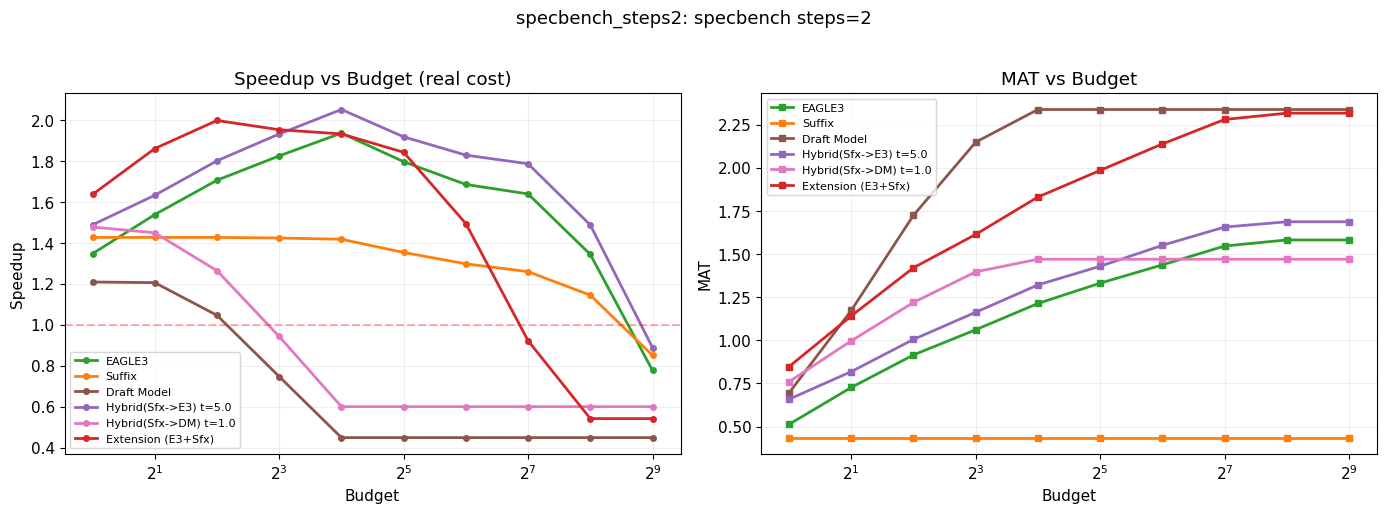

In [311]:
top_methods = mdf.head(6)['method'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in top_methods:
    col_spd = f'{name}{spd_suffix}'
    col_mat = f'{name}_mat'
    label = make_label(name)
    color = get_color(name)

    if col_spd in df.columns:
        ax1.plot(df['budget'], df[col_spd], 'o-', label=label, color=color, linewidth=2, markersize=4)
    if col_mat in df.columns:
        ax2.plot(df['budget'], df[col_mat], 's-', label=label, color=color, linewidth=2, markersize=4)

ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Budget')
ax1.set_ylabel('Speedup')
ax1.set_title(f'Speedup vs Budget ({COST_LABEL})')
ax1.set_xscale('log', base=2)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

ax2.set_xlabel('Budget')
ax2.set_ylabel('MAT')
ax2.set_title('MAT vs Budget')
ax2.set_xscale('log', base=2)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.suptitle(f'{SELECTED}: {workload_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Cross-steps Comparison (Same Workload, All Step Configs)

Workload='specbench', configs: ['specbench_steps2', 'specbench_steps4', 'specbench_steps6', 'specbench_steps8']


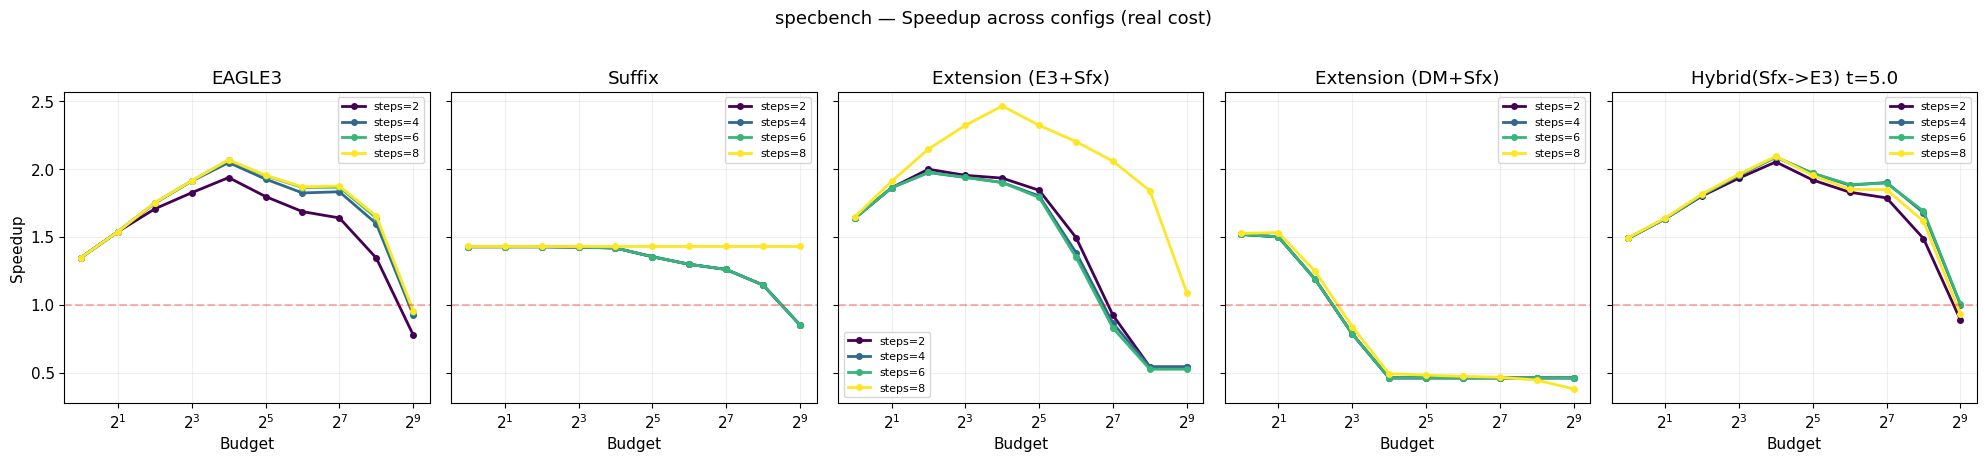

In [312]:
# Overlay speedup vs budget across the same workload's sweep axis
# (e.g. steps={2,4,6,8} for Phase 5 runs, or single-entry if only one).
HEADLINE_METHODS = ['eagle3', 'suffix', 'extension', 'extension_dmsfx', 'hybrid_e3_t5.0']

selected_workload, _sel_axis, _sel_val = _parse_dir_name(SELECTED)

# Collect all sibling configs for the same workload
peers = []
for key, (label, path) in WORKLOAD_OPTIONS.items():
    w, ax, v = _parse_dir_name(key)
    if w == selected_workload:
        peers.append((v if v is not None else 0, ax, key, label, path))
peers.sort(key=lambda x: (x[1] or '', x[0] if isinstance(x[0], int) else 0))

print(f"Workload='{selected_workload}', configs: {[k for _,_,k,_,_ in peers]}")

if len(peers) >= 2:
    fig, axes = plt.subplots(1, len(HEADLINE_METHODS),
                             figsize=(4 * len(HEADLINE_METHODS), 4.5), sharey=True)
    if len(HEADLINE_METHODS) == 1:
        axes = [axes]
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i / max(1, len(peers) - 1)) for i in range(len(peers))]

    for m_idx, m in enumerate(HEADLINE_METHODS):
        ax = axes[m_idx]
        for (v, axn, key, label, path), color in zip(peers, colors):
            with open(path) as f:
                d_i = json.load(f)
            df_i = pd.DataFrame(d_i['latency']['budget_sweep'])
            col = f'{m}{spd_suffix}'
            if col in df_i.columns:
                tag = f"{axn}={v}" if axn else key
                ax.plot(df_i['budget'], df_i[col], 'o-', color=color,
                        label=tag, linewidth=2, markersize=4)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
        ax.set_xlabel('Budget')
        if m_idx == 0:
            ax.set_ylabel('Speedup')
        ax.set_title(make_label(m))
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.suptitle(f'{selected_workload} — Speedup across configs ({COST_LABEL})',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Only 1 config for workload '{selected_workload}' — skipping sweep chart.")

## 8. Cross-workload Comparison (Same Steps, All Workloads)

steps=2, workloads: ['bfcl_v4', 'specbench', 'swebench']


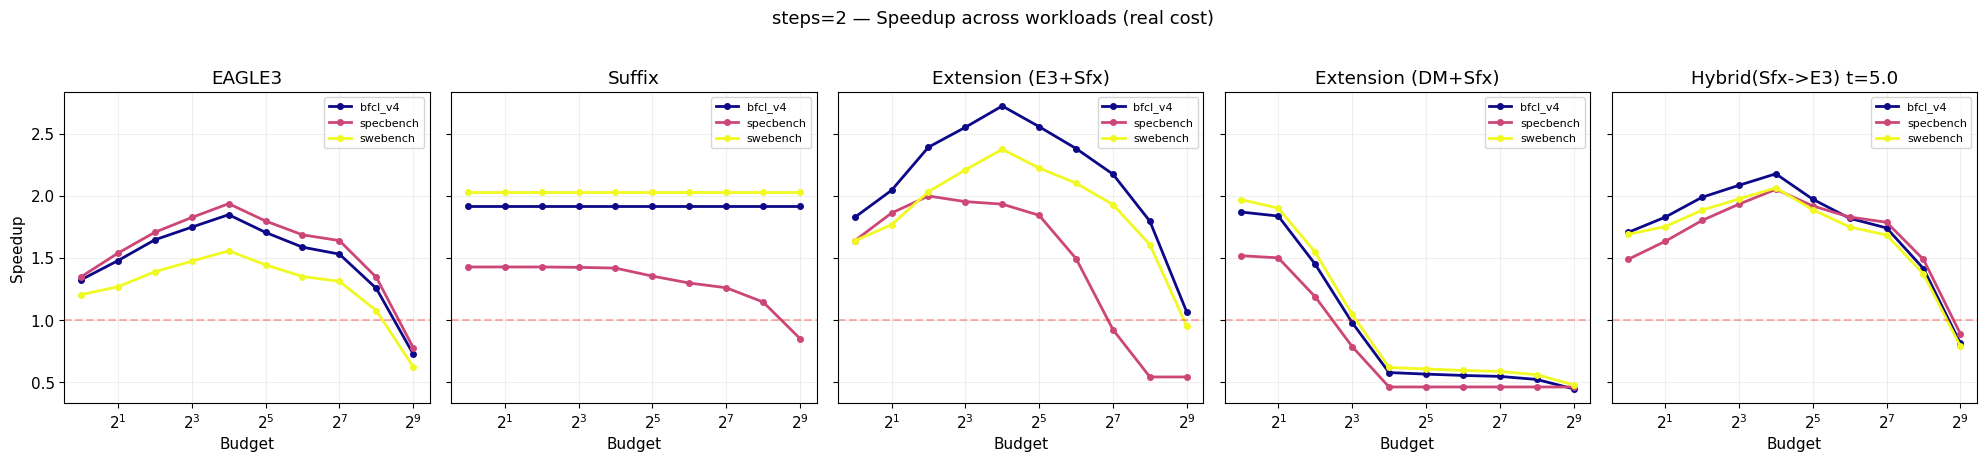

In [313]:
# Overlay speedup vs budget across workloads at the SELECTED config's axis
# value (e.g. same steps for Phase 5 runs). Groups by the selected axis so
# mango3-style _req configs and Phase 5 _steps configs don't get mixed.
_sel_workload, _sel_axis, _sel_val = _parse_dir_name(SELECTED)

peers = []
for key, (label, path) in WORKLOAD_OPTIONS.items():
    w, ax, v = _parse_dir_name(key)
    if ax == _sel_axis and v == _sel_val:
        peers.append((w, key, label, path))
peers.sort()

tag = f"{_sel_axis}={_sel_val}" if _sel_axis else "(single config)"
print(f"{tag}, workloads: {[w for w,_,_,_ in peers]}")

if len(peers) >= 2:
    fig, axes = plt.subplots(1, len(HEADLINE_METHODS),
                             figsize=(4 * len(HEADLINE_METHODS), 4.5), sharey=True)
    if len(HEADLINE_METHODS) == 1:
        axes = [axes]
    cmap = plt.get_cmap('plasma')
    colors = [cmap(i / max(1, len(peers) - 1)) for i in range(len(peers))]

    for m_idx, m in enumerate(HEADLINE_METHODS):
        ax = axes[m_idx]
        for (wname, key, label, path), color in zip(peers, colors):
            with open(path) as f:
                d_i = json.load(f)
            df_i = pd.DataFrame(d_i['latency']['budget_sweep'])
            col = f'{m}{spd_suffix}'
            if col in df_i.columns:
                ax.plot(df_i['budget'], df_i[col], 'o-', color=color,
                        label=wname, linewidth=2, markersize=4)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
        ax.set_xlabel('Budget')
        if m_idx == 0:
            ax.set_ylabel('Speedup')
        ax.set_title(make_label(m))
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.suptitle(f'{tag} — Speedup across workloads ({COST_LABEL})',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Need ≥2 workloads at {tag}")